# Proposition 1 (NN Encoder, Finite Samples, Gradient Descent, Multivariate)
This notebook tests Proposition 1 dynamics with a multivariate neural-network encoder.
We train with finite samples by gradient descent on
\[
\mathcal{L}(\theta,\mu)=\frac12\,\mathbb{E}_n\left[\|f_\theta(X)-Y\mu\|_2^2\right],
\]
for balanced labels \(Y\in\{-1,+1\}\), input \(X\in\mathbb{R}^{d_x}\), latent output \(f_\theta(X)\in\mathbb{R}^{d_z}\), and \(\mu\in\mathbb{R}^{d_z}\).
We plot the empirical dynamics of:
- \($\|\mu_t\|_2$\)
- \($\|\mathbb{E}_n[Y f_{\theta_t}(X)]\|_2$\)
- \($\|f_t\|_{L^2(n)} := \sqrt{\mathbb{E}_n[\|f_{\theta_t}(X)\|_2^2]}$\)


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)


In [2]:
# Configuration
cfg = {
    "m_values": [1.0, 2.0],   # class-separation magnitude for +/-m_vec
    "d_in": 8,                    # input dimension
    "d_latent": 4,                # latent/output dimension of encoder
    "n_train": 4000,               # finite sample size
    "steps": 2000,                 # gradient-descent iterations
    "lr": 3e-3,                    # optimizer learning rate
    "hidden": 128,                 # hidden width of encoder
    "depth": 2,                    # hidden layers (>=1)
    "seed": 7,
    "device": "cpu",
    "print_every": 500,
}


In [3]:
def make_m_vector(d_in, m, seed, device="cpu"):
    g = torch.Generator(device=device)
    g.manual_seed(seed + 1000)
    v = torch.randn(d_in, generator=g, device=device)
    v = v / (torch.linalg.norm(v) + 1e-12)
    return m * v


def make_dataset(n, d_in, m, seed, device="cpu"):
    g = torch.Generator(device=device)
    g.manual_seed(seed)

    m_vec = make_m_vector(d_in=d_in, m=m, seed=seed, device=device)

    y = torch.where(torch.rand(n, generator=g, device=device) < 0.5, -1.0, 1.0).view(-1, 1)
    eps = torch.randn(n, d_in, generator=g, device=device)
    x = y * m_vec.view(1, -1) + eps
    return x, y, m_vec


class EncoderNN(torch.nn.Module):
    def __init__(self, d_in=8, d_latent=4, hidden=128, depth=2):
        super().__init__()
        layers = []
        in_dim = d_in
        for _ in range(depth):
            layers.append(torch.nn.Linear(in_dim, hidden))
            layers.append(torch.nn.ReLU())
            in_dim = hidden
        layers.append(torch.nn.Linear(in_dim, d_latent))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_single(m, d_in, d_latent, n_train, steps, lr, hidden, depth, seed, device="cpu", print_every=500):
    x, y, m_vec = make_dataset(n=n_train, d_in=d_in, m=m, seed=seed, device=device)

    # Empirical kappa and theoretical decay rate from Proposition 1
    with torch.no_grad():
        proj = x @ m_vec.view(-1, 1)
        kappa = torch.mean(torch.tanh(proj) ** 2).item()
    rate_bound = max(0.0, 1.0 - np.sqrt(kappa))

    model = EncoderNN(d_in=d_in, d_latent=d_latent, hidden=hidden, depth=depth).to(device)
    # vector trainable class mean parameter
    mu = torch.nn.Parameter(torch.ones(d_latent, device=device))

    opt = torch.optim.SGD(list(model.parameters()) + [mu], lr=lr)

    hist = {
        "abs_mu": np.zeros(steps),
        "abs_EYf": np.zeros(steps),
        "abs_f": np.zeros(steps),
        "loss": np.zeros(steps),
        "kappa": kappa,
        "rate_bound": rate_bound,
    }

    for t in range(steps):
        f = model(x)  # (n, d_latent)
        resid = f - y * mu.view(1, -1)
        loss = 0.5 * torch.mean(torch.sum(resid ** 2, dim=1))

        opt.zero_grad()
        loss.backward()
        opt.step()

        with torch.no_grad():
            f_now = model(x)
            Eyf_vec = torch.mean(y * f_now, dim=0)
            f_norm = torch.sqrt(torch.mean(torch.sum(f_now ** 2, dim=1)))

            hist["abs_mu"][t] = torch.linalg.norm(mu).item()
            hist["abs_EYf"][t] = torch.linalg.norm(Eyf_vec).item()
            hist["abs_f"][t] = torch.abs(f_norm).item()
            hist["loss"][t] = loss.item()

        if (t + 1) % print_every == 0:
            print(
                f"m={m:.2f} step {t+1:4d}/{steps} "
                f"kappa={kappa:.4f} rate<={rate_bound:.4e} "
                f"|mu|={hist['abs_mu'][t]:.4e} "
                f"|E[Yf]|={hist['abs_EYf'][t]:.4e} "
                f"|f|={hist['abs_f'][t]:.4e} "
                f"loss={hist['loss'][t]:.4e}"
            )

    return hist


In [4]:
all_hist = {}
for m in cfg["m_values"]:
    print("=" * 80)
    all_hist[m] = run_single(
        m=m,
        d_in=cfg["d_in"],
        d_latent=cfg["d_latent"],
        n_train=cfg["n_train"],
        steps=cfg["steps"],
        lr=cfg["lr"],
        hidden=cfg["hidden"],
        depth=cfg["depth"],
        seed=cfg["seed"],
        device=cfg["device"],
        print_every=cfg["print_every"],
    )


m=1.00 step  500/2000 kappa=0.5419 rate<=2.6389e-01 |mu|=7.5256e-01 |E[Yf]|=4.1338e-01 |f|=6.0673e-01 loss=1.5658e-01
m=1.00 step 1000/2000 kappa=0.5419 rate<=2.6389e-01 |mu|=4.0763e-01 |E[Yf]|=2.5382e-01 |f|=3.7323e-01 loss=4.9370e-02
m=1.00 step 1500/2000 kappa=0.5419 rate<=2.6389e-01 |mu|=2.3989e-01 |E[Yf]|=1.6052e-01 |f|=2.4019e-01 loss=1.9145e-02
m=1.00 step 2000/2000 kappa=0.5419 rate<=2.6389e-01 |mu|=1.5022e-01 |E[Yf]|=1.0602e-01 |f|=1.6457e-01 loss=8.9108e-03
m=2.00 step  500/2000 kappa=0.9280 rate<=3.6654e-02 |mu|=1.2463e+00 |E[Yf]|=1.0437e+00 |f|=1.1576e+00 loss=1.4598e-01
m=2.00 step 1000/2000 kappa=0.9280 rate<=3.6654e-02 |mu|=9.8702e-01 |E[Yf]|=8.3978e-01 |f|=9.2397e-01 loss=8.5176e-02
m=2.00 step 1500/2000 kappa=0.9280 rate<=3.6654e-02 |mu|=7.9543e-01 |E[Yf]|=6.8503e-01 |f|=7.4933e-01 loss=5.2261e-02
m=2.00 step 2000/2000 kappa=0.9280 rate<=3.6654e-02 |mu|=6.5042e-01 |E[Yf]|=5.6611e-01 |f|=6.1624e-01 loss=3.3219e-02


Slope comparison (fit vs theory), using GD steps >= 500:
m=1.0  mu=-3.557168e-01  Eyf=-3.047788e-01  f=-2.926381e-01  th=-2.638942e-01
m=2.0  mu=-1.442062e-01  Eyf=-1.358798e-01  f=-1.398965e-01  th=-3.665374e-02


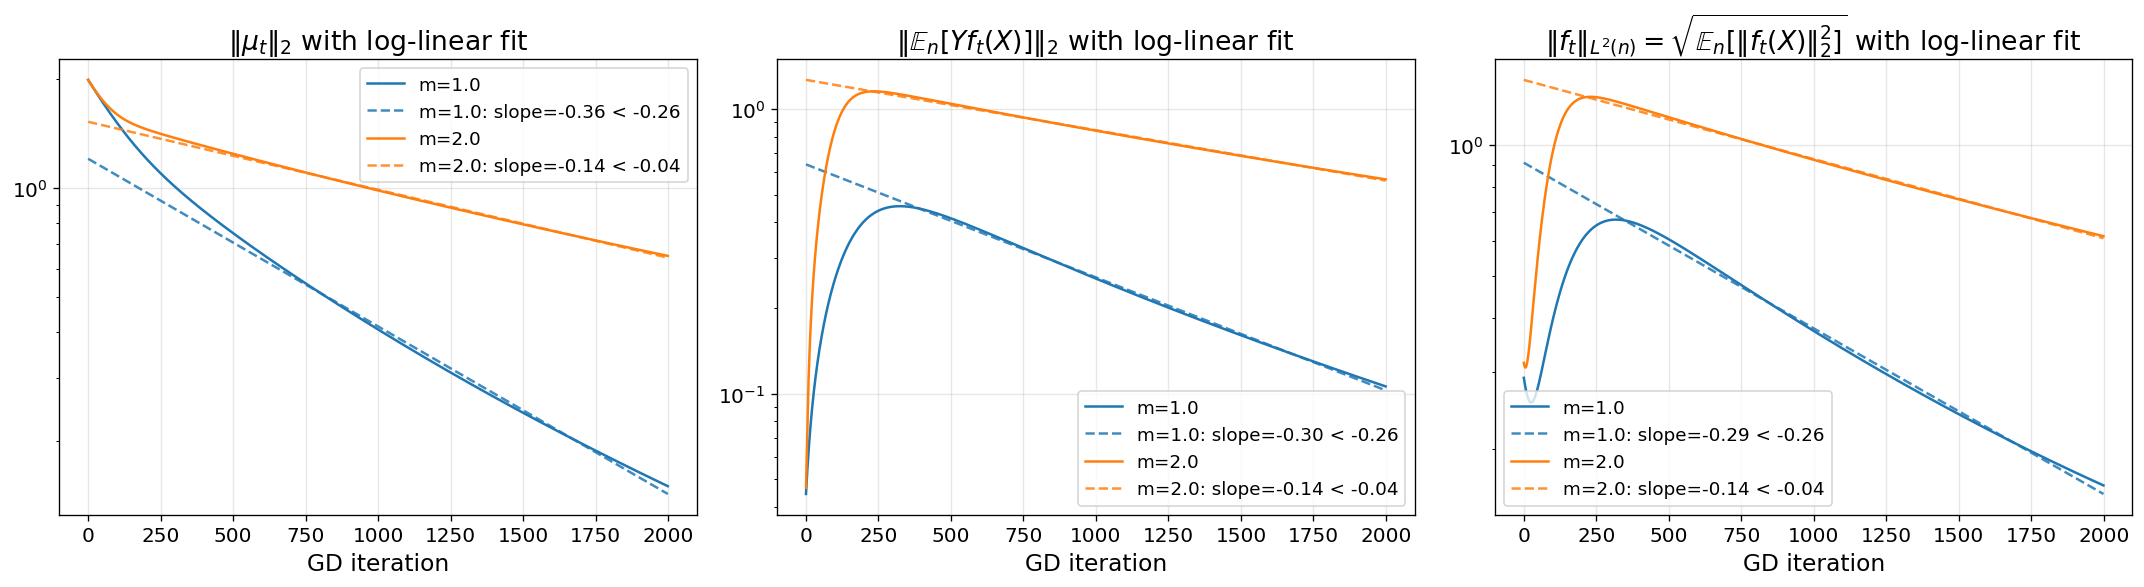

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
slope_rows = []
fit_start_step = 500
title_fs = 16
label_fs = 14
tick_fs = 12
legend_fs = 11
for m in cfg["m_values"]:
    h = all_hist[m]
    # Empirical curves
    line = axes[0].plot(h["abs_mu"], label=f"m={m}")[0]
    axes[1].plot(h["abs_EYf"], label=f"m={m}", color=line.get_color())
    axes[2].plot(h["abs_f"], label=f"m={m}", color=line.get_color())
    n = np.arange(len(h["abs_mu"]))
    t = n * cfg["lr"]
    slope_theory = -(1.0 - np.sqrt(h["kappa"]))
    # |mu_t| fit
    mu = np.asarray(h["abs_mu"])
    mask_mu = np.isfinite(mu) & (mu > 0) & (n >= fit_start_step)
    slope_mu, intercept_mu = np.polyfit(t[mask_mu], np.log(mu[mask_mu]), 1)
    mu_fit = np.exp(intercept_mu + slope_mu * t)
    comp_mu = "<" if slope_mu < slope_theory else ">="
    axes[0].plot(
        mu_fit, linestyle="--", color=line.get_color(), alpha=0.85,
        label=f"m={m}: slope={slope_mu:.2f} {comp_mu} {slope_theory:.2f}"
    )
    # |E[Y f_t(X)]| fit
    eyf = np.asarray(h["abs_EYf"])
    mask_eyf = np.isfinite(eyf) & (eyf > 0) & (n >= fit_start_step)
    slope_eyf, intercept_eyf = np.polyfit(t[mask_eyf], np.log(eyf[mask_eyf]), 1)
    eyf_fit = np.exp(intercept_eyf + slope_eyf * t)
    comp_eyf = "<" if slope_eyf < slope_theory else ">="
    axes[1].plot(
        eyf_fit, linestyle="--", color=line.get_color(), alpha=0.85,
        label=f"m={m}: slope={slope_eyf:.2f} {comp_eyf} {slope_theory:.2f}"
    )
    # |f_t| fit
    fval = np.asarray(h["abs_f"])
    mask_f = np.isfinite(fval) & (fval > 0) & (n >= fit_start_step)
    slope_f, intercept_f = np.polyfit(t[mask_f], np.log(fval[mask_f]), 1)
    f_fit = np.exp(intercept_f + slope_f * t)
    comp_f = "<" if slope_f < slope_theory else ">="
    axes[2].plot(
        f_fit, linestyle="--", color=line.get_color(), alpha=0.85,
        label=f"m={m}: slope={slope_f:.2f} {comp_f} {slope_theory:.2f}"
    )
    slope_rows.append((m, slope_mu, slope_eyf, slope_f, slope_theory))
axes[0].set_title(r"$\|\mu_t\|_2$ with log-linear fit", fontsize=title_fs)
axes[1].set_title(r"$\|\mathbb{E}_n[Y f_t(X)]\|_2$ with log-linear fit", fontsize=title_fs)
axes[2].set_title(r"$\|f_t\|_{L^2(n)}=\sqrt{\mathbb{E}_n[\|f_t(X)\|_2^2]}$ with log-linear fit", fontsize=title_fs)
for ax in axes:
    ax.set_xlabel("GD iteration", fontsize=label_fs)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=legend_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)
print(f"Slope comparison (fit vs theory), using GD steps >= {fit_start_step}:")
for m, s_mu, s_eyf, s_f, s_th in slope_rows:
    print(
        f"m={m:.1f}  mu={s_mu:.6e}  Eyf={s_eyf:.6e}  f={s_f:.6e}  th={s_th:.6e}"
    )
plt.tight_layout()
plt.savefig("gd_dynamics.png", dpi=600)


## Notes

- This is finite-sample training (empirical expectations over `n_train` samples).
- Input is multivariate (`d_in`) and latent output is multivariate (`d_latent`).
- In all three panels, dashed lines are log-linear regressions versus `t = step * lr`.
- Regression fitting uses only GD steps `>= 500`.
- Plot notation uses norms: `||mu_t||_2`, `||E_n[Yf_t(X)]||_2`, and `||f_t||_{L^2(n)}`.
- Legend format is `slope=<empirical> <or>= <theory>`, where theory is `-(1 - sqrt(kappa))`.
- Here `kappa = E_n[tanh^2(m_vec^T X)]` with class-separation vector `m_vec` of norm `m`.
- The notebook prints slope summaries for the three norm curves.
